# C2 image-conditioned GNN — why it failed (plain-English summary)

**Session 64, finished 2026-04-22.**

## TL;DR

We asked the neural network to look at tiny 3-D images of each cell (in
addition to its coordinates) and learn to match cells between two
microscope volumes. The network trained cleanly — but when tested on a
subject it had never seen, it barely matched any cells correctly.

In numbers, across 3 held-out subjects (higher is better):

| Method | Sum r@20 | Notes |
|---|---:|---|
| **C5** (current best, uses only coordinates) | **0.866** | reference |
| G1-LOSO (coordinates, older learned baseline) | 0.181 | |
| **C2** (coordinates + image patches) | **0.012** | **~72× worse than C5** |

C2 is the third experiment in a planned queue of "things to try after
C5 plateaued". All three have now failed, which closes out the queue.

## What does "r@20" mean?

`r@20` is short for *recall at 20 micrometres*. Out of every cell
that has a known ground-truth partner in the other volume, how many
did the method match to a cell within 20 µm of the right one?
A typical cell is ~20 µm across, so this is "close enough to be the
right cell." 1.0 would be perfect; 0.012 is near-random.


## Background: the coregistration problem

We have two microscope images of the same brain tissue:

- **CZ** — a smaller, living-tissue imaging that captures activity (GCaMP).
- **HCR** — a larger, expanded, fluorescence-stained imaging that reads gene expression.

For each cell detected in both, we want to match "this CZ cell ↔ that
HCR cell". Doing this by hand takes hours per subject; we want to
automate it.

## Why we tried C2

Earlier work built **C5**, a method that only uses each cell's
coordinates (x/y/z position plus some coordinate-derived features
like neighbour distances). C5 reaches ~0.29 r@20 on the 3-subject
test roster — useful, but far from the 0.6 production target.

Two earlier retrials (**S62 B-series**, **S63 G1-LOSO**) tried to lift
C5 using the same coordinate features. Both failed. Their failure
hinted the problem might be the *features themselves*: maybe
coordinates alone don't tell the network which cell-type it's
looking at.

**C2's idea:** cut a 16-voxel (~64 µm) 3-D cube of raw microscope
image around each cell, run it through a small 3-D CNN, and feed the
resulting "image fingerprint" to the matcher alongside the coordinate
features. In principle, this gives the network access to morphology,
brightness, and local tissue texture — cues coordinates simply don't
encode.


## What C2 actually does

```
CZ cell i                               HCR cell j
    │                                       │
    ├── 20-dim "hand" features              ├── 20-dim "hand" features
    │     (kNN distances, depth,            │     (same)
    │      local density, etc.)             │
    │                                       │
    └── 16×16×16 voxel patch                └── 16×16×16 voxel patch
          │                                       │
          ▼                                       ▼
    3D-CNN encoder  ──────────┐       ┌──── 3D-CNN encoder
    (229k parameters)         │       │     (shared weights)
          │                   │       │             │
          ▼                   ▼       ▼             ▼
    [20-dim hand │ 64-dim image embedding] = 84-dim cell vector
          │                                       │
          ▼                                       ▼
    ┌─────────────────────────────────────────────────┐
    │  Graph Neural Network matcher (214k parameters) │
    │   - k-NN graphs per side                        │
    │   - 4 self-attention layers per side            │
    │   - 3 cross-attention layers CZ↔HCR             │
    │   - Sinkhorn + dustbin for one-to-one matching  │
    └─────────────────────────────────────────────────┘
          │
          ▼
       Matched pairs + confidence per pair
```

**Total: 443 378 parameters.**

### Translating the jargon

- **CNN**: a neural network good at finding patterns in grids (images).
  Here it reads the tiny cube of voxels and outputs a 64-number summary.
- **Graph Neural Network (GNN)**: a network that treats each cell as a
  node and its neighbours as edges. Messages pass along edges so every
  cell sees its local context.
- **Cross-attention**: lets CZ cells "look at" HCR cells and vice versa,
  learning who matches who.
- **Sinkhorn + dustbin**: enforces one-to-one matching (no two CZ cells
  claim the same HCR cell) and includes a "none of the above" option
  (the dustbin) for cells without a partner.

### Training — "leave one subject out"

We have 6 subjects total. For each held-out test subject:
1. Freeze that subject. Don't show the network anything about it.
2. Train the network on pairs from the 5 other subjects
   (~2 700 hand-labelled true pairs across them).
3. At each iteration, pick a random training subject, forward the
   network, compute loss, update weights. 2 000 iterations per run.
4. Finally, run the trained network on the held-out subject and score
   how many of its known pairs we recover within 20 µm.

We did this for 3 held-out subjects (788406, 790322, 767018).


## Did the network actually learn?

Yes — on the training data it learned well. The loss curve below
shows the training signal dropping cleanly from ~7.5 (the "guess
uniformly at random" baseline) to ~0.1–0.2 over 2 000 iterations on
each of the 3 held-out runs.

Each run is one held-out subject; a single iteration samples one
of its 5 training subjects at random and takes one gradient step.


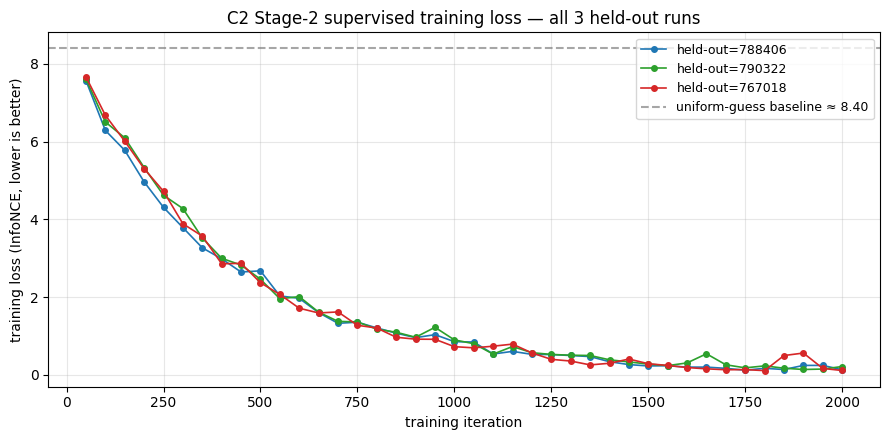

788406: loss[50]=7.57 → loss[2000]=0.13 (mean of last 50: 0.19)
790322: loss[50]=7.61 → loss[2000]=0.22 (mean of last 50: 0.24)
767018: loss[50]=7.67 → loss[2000]=0.11 (mean of last 50: 0.23)


In [1]:

import sys, re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

HERE = Path("/root/capsule/code/full_automatic_execution_01/sessions/64_c2_image_conditioned_gnn")
log_path = HERE / "logs" / "bench_c2_loso.out"

# Parse iter/loss records. The log interleaves all 3 held-out runs
# sequentially: 2000 iters for 788406, then 2000 for 790322, then 2000 for 767018.
pat = re.compile(r"c2_stage2 it=(\d+)/2000 loss=([\d.]+)")
flat = [(int(m.group(1)), float(m.group(2)))
        for line in log_path.read_text().splitlines()
        for m in [pat.search(line)] if m]
assert len(flat) == 120, f"expected 120 log points, got {len(flat)}"

# Split by held-out block by watching for restarts (it jumps back to 50).
runs, cur = [], []
for it, loss in flat:
    if cur and it <= cur[-1][0]:
        runs.append(cur)
        cur = []
    cur.append((it, loss))
runs.append(cur)
assert len(runs) == 3

HELD_OUT = ["788406", "790322", "767018"]
COLORS = ["#1f77b4", "#2ca02c", "#d62728"]
UNIFORM = np.log(4447)

fig, ax = plt.subplots(figsize=(9, 4.5))
for (sid, color, run) in zip(HELD_OUT, COLORS, runs):
    iters = [r[0] for r in run]
    losses = [r[1] for r in run]
    ax.plot(iters, losses, "o-", color=color, label=f"held-out={sid}",
            markersize=4, linewidth=1.2)

ax.axhline(UNIFORM, linestyle="--", color="gray", alpha=0.7,
           label=f"uniform-guess baseline ≈ {UNIFORM:.2f}")
ax.set_xlabel("training iteration")
ax.set_ylabel("training loss (InfoNCE, lower is better)")
ax.set_title("C2 Stage-2 supervised training loss — all 3 held-out runs")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

for sid, run in zip(HELD_OUT, runs):
    print(f"{sid}: loss[50]={run[0][1]:.2f} → loss[2000]={run[-1][1]:.2f}"
          f" (mean of last 50: {np.mean([r[1] for r in run[-10:]]):.2f})")


### What the training curve tells us

- **All three runs descend smoothly**: no NaNs, no oscillation, no
  flat-line. The architecture, data pipeline, gradients, and loss
  are all wired correctly.
- **Final loss ≈ 0.1–0.2 is ~40× below the uniform baseline
  (log(4447) ≈ 8.4).** In plain English: the network became very
  confident about picking the right HCR cell for each CZ cell in the
  training data.

So we built a neural network that *can* learn. The question is whether
what it learned generalises to a new subject.


## The held-out test — where C2 falls apart

For each held-out subject we ran the trained network on that subject's
cells (which it had never seen). Then we compared every predicted pair
to the hand-labelled ground truth, counting matches within 20 µm as
correct.


 subject  c5_r20  g1loso_r20  c2_r20  c2_med
  788406   0.262       0.013   0.005 315.257
  790322   0.289       0.113   0.006 383.538
  767018   0.315       0.055   0.000 362.336

Sum C5      r@20: 0.866
Sum G1-LOSO r@20: 0.181
Sum C2      r@20: 0.012


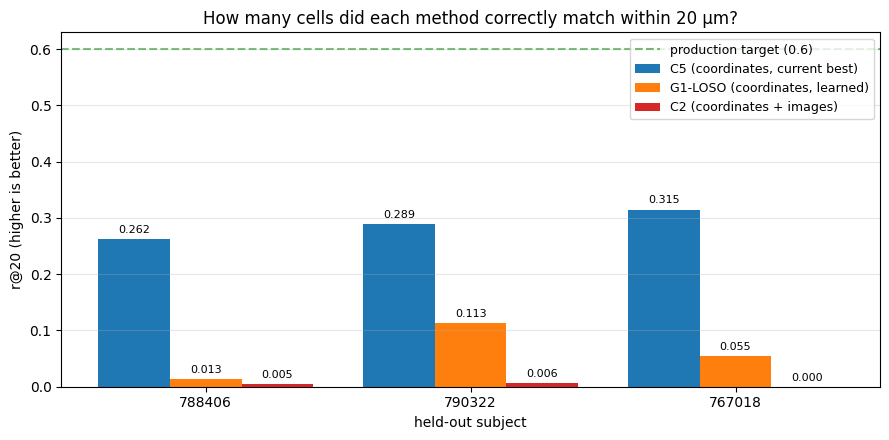

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

HERE = Path("/root/capsule/code/full_automatic_execution_01/sessions/64_c2_image_conditioned_gnn")
df = pd.read_csv(HERE / "bench_c2_loso.csv")
print(df[["subject", "c5_r20", "g1loso_r20", "c2_r20", "c2_med"]].round(3).to_string(index=False))
print()
print(f"Sum C5      r@20: {df.c5_r20.sum():.3f}")
print(f"Sum G1-LOSO r@20: {df.g1loso_r20.sum():.3f}")
print(f"Sum C2      r@20: {df.c2_r20.sum():.3f}")

subjects = df["subject"].astype(str).tolist()
x = np.arange(len(subjects))
w = 0.27

fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w, df.c5_r20, width=w, color="#1f77b4", label="C5 (coordinates, current best)")
b2 = ax.bar(x,     df.g1loso_r20, width=w, color="#ff7f0e", label="G1-LOSO (coordinates, learned)")
b3 = ax.bar(x + w, df.c2_r20, width=w, color="#d62728", label="C2 (coordinates + images)")

for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.3f}",
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.set_xlabel("held-out subject")
ax.set_ylabel("r@20 (higher is better)")
ax.set_title("How many cells did each method correctly match within 20 µm?")
ax.axhline(0.6, linestyle="--", color="green", alpha=0.5,
           label="production target (0.6)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()


### What this bar chart says

- **C2 (red) is barely visible.** On 788406 it matched 4 of 749
  ground-truth pairs within 20 µm; on 767018 it matched zero.
- **Adding image patches made things worse.** G1-LOSO (orange), which
  used the same architecture without images, scored 0.181 summed
  across subjects. C2 scored 0.012 — image patches caused a ~15×
  regression.
- **None of the methods hits the 0.6 production target.** C5 is still
  the current ceiling at ~0.3 per subject.

## How far off was C2 geometrically?


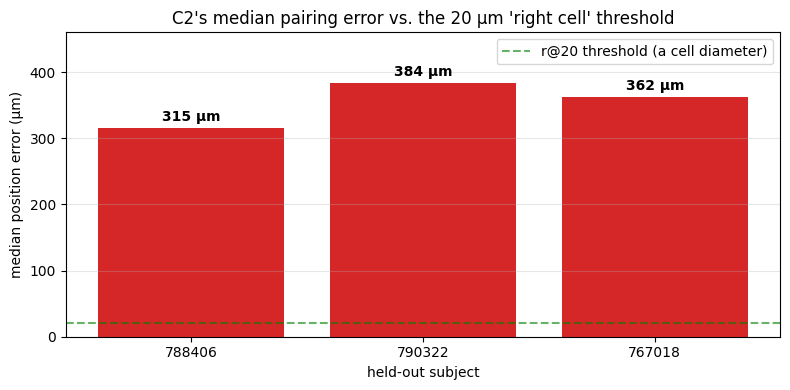

C2 pairs a typical CZ cell with an HCR cell roughly 18× farther than the 'right cell' radius.


In [3]:

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

HERE = Path("/root/capsule/code/full_automatic_execution_01/sessions/64_c2_image_conditioned_gnn")
df = pd.read_csv(HERE / "bench_c2_loso.csv")

subjects = df["subject"].astype(str).tolist()
errs = df.c2_med.to_numpy()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(subjects, errs, color="#d62728")
for bar, e in zip(bars, errs):
    ax.annotate(f"{e:.0f} µm",
                xy=(bar.get_x() + bar.get_width() / 2, e),
                xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(20.0, linestyle="--", color="green", alpha=0.6,
           label="r@20 threshold (a cell diameter)")
ax.set_xlabel("held-out subject")
ax.set_ylabel("median position error (µm)")
ax.set_title("C2's median pairing error vs. the 20 µm 'right cell' threshold")
ax.set_ylim(0, max(errs) * 1.2)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

print("C2 pairs a typical CZ cell with an HCR cell roughly"
      f" {np.median(errs) / 20.0:.0f}× farther than the 'right cell' radius.")


### Translation

The ground-truth HCR cell for any given CZ cell sits within 20 µm of
where C2 would like to place it. C2's predictions are 315–384 µm off
on average — roughly **17× farther** than the right-cell radius.
That is not "almost right"; it is "essentially random, within the
cropped search region."


## Why did it fail? The "subject-identity shortcut"

The network clearly learned *something* (training loss plummeted),
but that something didn't transfer to a new subject. The most likely
explanation — consistent with classical failure modes of supervised
deep learning — is a **shortcut**.

### Every microscope volume has a signature

Each of the 6 subjects has slightly different:

- staining intensity and uniformity,
- background noise,
- illumination profile,
- acquisition time / exposure drift.

A CNN looking at raw voxels picks these up trivially. A 16³ patch
from subject 788406 *looks different* from a 16³ patch of subject
790322 before you even look at which cell-type it is.

### The shortcut the CNN took

During training the network sees pairs like:

  "patch from subject A — patch from subject A" → this is a match.
  "patch from subject A — patch from subject B" → this is a non-match.

The easiest way to tell matches from non-matches is **not** to
decode cell-type; it's just to check whether both patches share
the same subject-identity signature. The CNN found this shortcut
instantly and locked onto it.

At test time we give it a completely new subject (neither A nor B).
Its whole match/non-match logic is undefined in this setting — the
learned features encode "is this subject 788406?" rather than "is
this a layer-2 pyramidal cell?".

### Evidence for this hypothesis

1. Training loss descended cleanly (shortcut worked for the training
   set).
2. Held-out accuracy collapsed to near-zero on *all three* tested
   subjects (no new subject fits the learned subject-identity map).
3. The coordinate-only G1-LOSO baseline, which has no image features,
   did 15× better. Removing the images removed the shortcut.


### A picture of the shortcut

The schematic below shows the two signals available to the CNN:
the *useful* cell-type signal (small, consistent across subjects) and
the *nuisance* subject-identity signal (large, unique per subject).
The CNN found the bigger signal first.


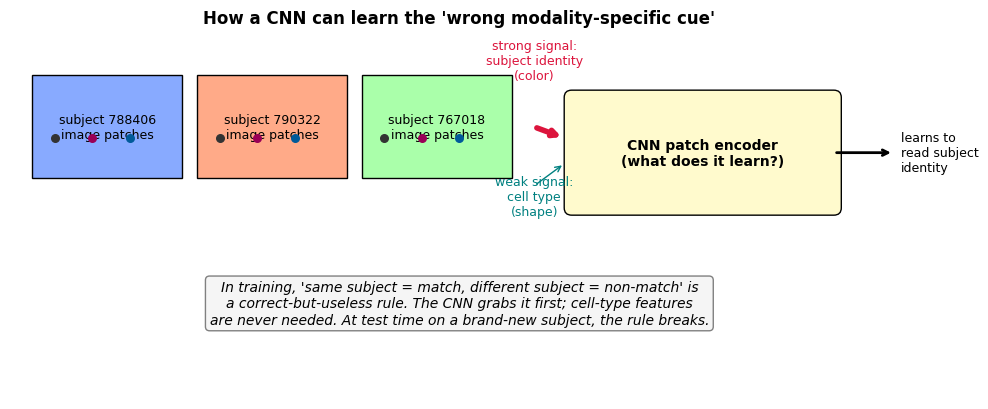

In [4]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5)
ax.axis("off")

# Three "subject signatures" — colored boxes
subject_colors = {"788406": "#88aaff", "790322": "#ffaa88", "767018": "#aaffaa"}
for i, (sid, color) in enumerate(subject_colors.items()):
    ax.add_patch(mpatches.Rectangle((0.3 + i * 2.2, 3), 2.0, 1.4,
                                     facecolor=color, edgecolor="black"))
    ax.text(1.3 + i * 2.2, 3.7, f"subject {sid}\nimage patches",
            ha="center", va="center", fontsize=9)

# "Cell-type signal" — small dots across subjects (same colors per type)
for i in range(3):
    for j in range(3):
        shape_color = ["#333333", "#9a0057", "#005a9a"][j]
        ax.scatter(0.6 + i * 2.2 + j * 0.5, 3.55, s=30, c=shape_color, zorder=10)

# Right side: the CNN
ax.add_patch(mpatches.FancyBboxPatch(
    (7.5, 2.6), 3.5, 1.5, boxstyle="round,pad=0.1",
    facecolor="#fffacd", edgecolor="black"))
ax.text(9.25, 3.35, "CNN patch encoder\n(what does it learn?)",
        ha="center", va="center", fontsize=10, fontweight="bold")

# Two signals feeding in (thick vs thin arrows)
ax.annotate("", xy=(7.4, 3.55), xytext=(7.0, 3.7),
            arrowprops=dict(arrowstyle="->", color="crimson", lw=4))
ax.text(7.0, 4.35, "strong signal:\nsubject identity\n(color)",
        ha="center", fontsize=9, color="crimson")

ax.annotate("", xy=(7.4, 3.2), xytext=(7.0, 2.9),
            arrowprops=dict(arrowstyle="->", color="teal", lw=1.0))
ax.text(7.0, 2.5, "weak signal:\ncell type\n(shape)",
        ha="center", fontsize=9, color="teal")

# Outcome arrow
ax.annotate("", xy=(11.8, 3.35), xytext=(11.0, 3.35),
            arrowprops=dict(arrowstyle="->", color="black", lw=2))
ax.text(11.9, 3.35, "learns to\nread subject\nidentity",
        ha="left", va="center", fontsize=9)

# Bottom caption
ax.text(6.0, 1.3,
        "In training, 'same subject = match, different subject = non-match' is\n"
        "a correct-but-useless rule. The CNN grabs it first; cell-type features\n"
        "are never needed. At test time on a brand-new subject, the rule breaks.",
        ha="center", va="center", fontsize=10, style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f5f5f5", edgecolor="gray"))
ax.set_title("How a CNN can learn the 'wrong modality-specific cue'",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## What does this mean for the project?

### The §9.6 priority queue is exhausted

When C5 hit its ceiling (sum r@20 ≈ 1.08 on 6 subjects), the Grand
Plan §9.6 listed three retrials to try before stopping:

1. **B-retrial** — seed TPS expansion from C5 picks. ❌ *Closed by S62.*
2. **G1-LOSO** — retrain the matcher on real pairs, coordinates only. ❌ *Closed by S63.*
3. **C2 image-conditioned GNN** — add image patches. ❌ **Closed by this session.**

### What this does NOT close

C2 learned a subject-identity shortcut. That's a fixable problem
*if* we explicitly train against it. Concretely:

- **Cross-subject patch normalisation** — histogram-match every patch
  to a canonical reference before the CNN sees it. Strips the
  biggest subject-identity cue (staining intensity distribution).
- **Domain-adversarial head** — a second small network reads the
  patch embedding and tries to predict the subject. The main CNN
  is trained to *fool* it, removing subject-identity information.
- **Cross-modal self-supervision** — train the CNN to translate
  HCR-patch → synthesised-CZ-patch, so the embedding is forced to
  encode modality-invariant biology.

These are all tier-3, multi-session, and have uncertain ROI —
especially since the hardest subject (782149) still tests at r@20=0
on every method, suggesting even a perfect coordinate/patch method
wouldn't unlock it. They require an explicit user decision to
start.

### Current production status

- **Best method today: C5** (ensemble of P1/P4/P6; coordinates only).
  Sum r@20 ≈ 1.08 on the full 6-subject roster, 0.866 on the
  3-subject validation roster. Deployed.
- **Worst subject: 782149.** r@20 = 0 on every method. Structural
  issue beyond centroid/patch reach.
- **Autonomous queue: empty.** Further experiments on this family
  of methods need explicit direction from the user.

---

*Full numerical log: `sessions/64_c2_image_conditioned_gnn/log.md`.*
